# Pista B - Problema inverso de parámetros

Para una ecuación de difusión o de Burgers con un coeficiente desconocido, recupere ese coeficiente a partir de observaciones dispersas y ruidosas, declarándolo como parámetro entrenable y añadiendo el término de datos $L_d$ Reproducir: la identificación del coeficiente y la reconstrucción del campo (con datos limpios y con 1% de ruido). Extender: estudiar la identificabilidad —¿cuántos sensores hacen falta?, ¿cuándo el problema se vuelve mal planteado?— o aplicar la idea a la ecuaci ́on de Fokker–Planck que vimos como cara distribucional de una EDE, infiriendo deriva y difusi ́on. Lecturas: Raissi et al. [2] (descubrimiento) y Chen et al. [7] (Fokker–Planck inverso). Corresponde al Ejemplo 3.

## 📌 Resumen del Notebook
En este cuaderno invertimos el paradigma. El objetivo es resolver un **Problema Inverso**: a partir de mediciones esparcidas y potencialmente ruidosas de un fluido, utilizaremos una PINN para reconstruir el campo completo de la solución y, simultáneamente, **descubrir los parámetros ocultos que gobiernan su física**.

Usaremos el dataset de la Ecuación de Burgers y demostraremos la robustez del modelo enfrentándolo a datos con ruido artificial y reduciendo drásticamente el número de sensores disponibles para estudiar su límite de identificabilidad.

## 1. Configuración, Compatibilidad y Datos ⚙️
Dado que este experimento se basa en la arquitectura fundacional de Raissi et al. (2019), utilizaremos el comportamiento de **TensorFlow 1.x** (`tf.disable_v2_behavior()`).

Además, descargaremos automáticamente el dataset `burgers_shock.mat`, el cual contiene simulaciones de alta fidelidad que actuarán como nuestros "sensores del mundo real". Finalmente, instalaremos paquetes de LaTeX en el entorno de Colab para generar gráficas con calidad de publicación.

In [5]:
!apt-get update
!apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super -y

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [6]:
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from scipy.interpolate import griddata
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
import time
import urllib.request
import os

## 2. Planteamiento Matemático: La Física Parametrizada 🧮

Asumimos que el fluido es observado, pero desconocemos los coeficientes exactos de su dinámica. Planteamos la ecuación de Burgers parametrizada:

$$\frac{\partial u}{\partial t} + \lambda_1 u \frac{\partial u}{\partial x} - \lambda_2 \frac{\partial^2 u}{\partial x^2} = 0$$

Donde:
* $\lambda_1$ es el coeficiente de convección no lineal (El valor real oculto es $1.0$).
* $\lambda_2$ es la viscosidad cinemática (El valor real oculto es $\nu = 0.01/\pi \approx 0.0031831$).

La red neuronal aprenderá los pesos $\theta$, y **al mismo tiempo**, $\lambda_1$ y $\lambda_2$ serán tratados como variables entrenables (`tf.Variable`) que se optimizarán mediante la minimización del residuo de la EDP.

## 3. Arquitectura PINN y el Optimizador L-BFGS-B 🧠
A diferencia de los optimizadores puros de gradiente estocástico como Adam, los métodos de cuasi-Newton como **L-BFGS-B** son fundamentales en las PINNs para alcanzar precisiones muy altas en paisajes de pérdida suaves.

Dado que TF1.x no posee un L-BFGS-B nativo fácil de enlazar con callbacks paramétricos, se implementa una clase `CustomScipyOptimizer` que actúa como puente bidireccional entre el grafo computacional de TensorFlow y el motor de optimización de SciPy.

In [7]:
if not os.path.exists('burgers_shock.mat'):
    print("Descargando dataset burgers_shock.mat...")
    urllib.request.urlretrieve("https://raw.githubusercontent.com/maziarraissi/PINNs/master/appendix/Data/burgers_shock.mat", "burgers_shock.mat")

np.random.seed(1234)
tf.set_random_seed(1234)

import scipy.optimize

class CustomScipyOptimizer:
    def __init__(self, sess, loss, var_list):
        self.sess = sess
        self.loss = loss
        self.var_list = var_list
        self.grads = tf.gradients(loss, var_list)

        # Guardamos las formas y tamaños de las variables
        self.shapes = [v.shape.as_list() for v in var_list]
        self.sizes = [int(np.prod(s)) for s in self.shapes]

        # Nodos para actualizar los pesos desde SciPy
        self.assign_ops = []
        self.placeholders = []
        for v, shape in zip(self.var_list, self.shapes):
            p = tf.placeholder(tf.float32, shape=shape)
            self.placeholders.append(p)
            self.assign_ops.append(tf.assign(v, p))

    def set_weights(self, flat_weights):
        offset = 0
        feed_dict = {}
        for p, shape, size in zip(self.placeholders, self.shapes, self.sizes):
            feed_dict[p] = flat_weights[offset:offset+size].reshape(shape)
            offset += size
        self.sess.run(self.assign_ops, feed_dict=feed_dict)

    def get_weights(self):
        weights = self.sess.run(self.var_list)
        return np.concatenate([w.flatten() for w in weights])

    def loss_and_grad(self, flat_weights, feed_dict):
        self.set_weights(flat_weights)
        loss_val, grads_val = self.sess.run([self.loss, self.grads], feed_dict=feed_dict)
        flat_grads = np.concatenate([g.flatten() for g in grads_val])
        return loss_val.astype(np.float64), flat_grads.astype(np.float64)

    def minimize(self, feed_dict, fetches=None, loss_callback=None, options=None):
        init_weights = self.get_weights()

        # Contador para imprimir cada N iteraciones
        self.iter_counter = 0

        def objective(weights):
            loss_val, grad_val = self.loss_and_grad(weights, feed_dict)
            self.iter_counter += 1
            if loss_callback and fetches and self.iter_counter % 100 == 0:
                fetched_vals = self.sess.run(fetches, feed_dict=feed_dict)
                loss_callback(*fetched_vals)
            return loss_val, grad_val

        # Llamada directa a L-BFGS-B de SciPy
        res = scipy.optimize.minimize(
            fun=objective,
            x0=init_weights,
            method='L-BFGS-B',
            jac=True,
            options=options
        )
        self.set_weights(res.x)
        print("L-BFGS-B Optimization Terminated:", res.message)

class PhysicsInformedNN:
  # Initialize the class
  def __init__(self, X, u, layers, lb, ub):
      self.lb = lb
      self.ub = ub
      self.x = X[:,0:1]
      self.t = X[:,1:2]
      self.u = u
      self.layers = layers

      # Initialize NNs
      self.weights, self.biases = self.initialize_NN(layers)

      # tf placeholders and graph
      self.sess = tf.Session(config=tf.ConfigProto(allow_soft_placement=True,
                                                    log_device_placement=False))

      # Initialize parameters
      self.lambda_1 = tf.Variable([0.0], dtype=tf.float32)
      self.lambda_2 = tf.Variable([-6.0], dtype=tf.float32)

      self.x_tf = tf.placeholder(tf.float32, shape=[None, self.x.shape[1]])
      self.t_tf = tf.placeholder(tf.float32, shape=[None, self.t.shape[1]])
      self.u_tf = tf.placeholder(tf.float32, shape=[None, self.u.shape[1]])

      self.u_pred = self.net_u(self.x_tf, self.t_tf)
      self.f_pred = self.net_f(self.x_tf, self.t_tf)

      self.loss = tf.reduce_mean(tf.square(self.u_tf - self.u_pred)) + \
                  tf.reduce_mean(tf.square(self.f_pred))

      variables = tf.trainable_variables()
      self.optimizer = CustomScipyOptimizer(self.sess, self.loss, variables)

      self.optimizer_Adam = tf.train.AdamOptimizer()
      self.train_op_Adam = self.optimizer_Adam.minimize(self.loss)

      init = tf.global_variables_initializer()
      self.sess.run(init)

  def initialize_NN(self, layers):
      weights = []
      biases = []
      num_layers = len(layers)
      for l in range(0,num_layers-1):
          W = self.xavier_init(size=[layers[l], layers[l+1]])
          b = tf.Variable(tf.zeros([1,layers[l+1]], dtype=tf.float32), dtype=tf.float32)
          weights.append(W)
          biases.append(b)
      return weights, biases

  def xavier_init(self, size):
      in_dim = size[0]
      out_dim = size[1]
      xavier_stddev = np.sqrt(2/(in_dim + out_dim))
      return tf.Variable(tf.truncated_normal([in_dim, out_dim], stddev=xavier_stddev), dtype=tf.float32)

  def neural_net(self, X, weights, biases):
      num_layers = len(weights) + 1

      H = 2.0*(X - self.lb)/(self.ub - self.lb) - 1.0
      for l in range(0,num_layers-2):
          W = weights[l]
          b = biases[l]
          H = tf.tanh(tf.add(tf.matmul(H, W), b))
      W = weights[-1]
      b = biases[-1]
      Y = tf.add(tf.matmul(H, W), b)
      return Y

  def net_u(self, x, t):
      u = self.neural_net(tf.concat([x,t],1), self.weights, self.biases)
      return u

  def net_f(self, x, t):
      lambda_1 = self.lambda_1
      lambda_2 = tf.exp(self.lambda_2)
      u = self.net_u(x,t)
      u_t = tf.gradients(u, t)[0]
      u_x = tf.gradients(u, x)[0]
      u_xx = tf.gradients(u_x, x)[0]
      f = u_t + lambda_1*u*u_x - lambda_2*u_xx

      return f

  def callback(self, loss, lambda_1, lambda_2):
      print('Loss: %e, l1: %.5f, l2: %.5f' % (loss, lambda_1, np.exp(lambda_2)))

  def train(self, nIter):
      tf_dict = {self.x_tf: self.x, self.t_tf: self.t, self.u_tf: self.u}

      start_time = time.time()
      for it in range(nIter):
          self.sess.run(self.train_op_Adam, tf_dict)

          # Print
          if it % 1000 == 0:
              elapsed = time.time() - start_time
              loss_value = self.sess.run(self.loss, tf_dict)
              lambda_1_value = self.sess.run(self.lambda_1)
              lambda_2_value = np.exp(self.sess.run(self.lambda_2))
              print('It: %d, Loss: %.3e, Lambda_1: %.3f, Lambda_2: %.6f, Time: %.2f' %
                    (it, loss_value, lambda_1_value[0], lambda_2_value[0], elapsed))
              start_time = time.time()

      self.optimizer.minimize(feed_dict = tf_dict,
                              fetches = [self.loss, self.lambda_1, self.lambda_2],
                              loss_callback = self.callback,
                              options = {'maxiter': 50000,
                                          'maxfun': 50000,
                                          'maxcor': 50,
                                          'maxls': 50,
                                          'ftol' : 1.0 * np.finfo(float).eps})


  def predict(self, X_star):

      tf_dict = {self.x_tf: X_star[:,0:1], self.t_tf: X_star[:,1:2]}

      u_star = self.sess.run(self.u_pred, tf_dict)
      f_star = self.sess.run(self.f_pred, tf_dict)

      return u_star, f_star


Descargando dataset burgers_shock.mat...


## 4. Resultados del Problema Inverso 📊
Tras entrenar el modelo con los 2000 sensores (tanto en el escenario ideal como en el escenario con 1% de ruido artificial), proyectamos los campos reconstruidos de la velocidad del fluido $u(t,x)$.

A continuación, generamos la tabla comparativa donde contrastamos los parámetros reales de la ecuación de Burgers frente a los parámetros $\lambda_1$ y $\lambda_2$ que la red neuronal logró "descubrir" de forma autónoma.

/tmp/ipykernel_40011/3071487642.py:158: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Loss: %e, l1: %.5f, l2: %.5f' % (loss, lambda_1, np.exp(lambda_2)))


Loss: 1.962726e-02, l1: 0.27938, l2: 0.00268
Loss: 9.686725e-03, l1: 0.52876, l2: 0.00346
Loss: 5.206509e-03, l1: 0.78756, l2: 0.00525
Loss: 2.246519e-03, l1: 0.89637, l2: 0.00605
Loss: 1.044699e-03, l1: 0.94324, l2: 0.00511
Loss: 5.638593e-04, l1: 0.97718, l2: 0.00484
Loss: 3.422144e-04, l1: 0.97945, l2: 0.00448
Loss: 2.282382e-04, l1: 0.98803, l2: 0.00417
Loss: 1.657306e-04, l1: 0.99285, l2: 0.00391
Loss: 1.278570e-04, l1: 0.98660, l2: 0.00368
Loss: 1.096261e-04, l1: 0.99499, l2: 0.00358
Loss: 9.164125e-05, l1: 0.99134, l2: 0.00349
Loss: 7.946447e-05, l1: 0.99259, l2: 0.00337
Loss: 7.084070e-05, l1: 0.99402, l2: 0.00333
Loss: 5.924367e-05, l1: 0.99077, l2: 0.00325
Loss: 4.859475e-05, l1: 0.99410, l2: 0.00320
Loss: 4.152592e-05, l1: 0.99619, l2: 0.00318
Loss: 3.601726e-05, l1: 0.99544, l2: 0.00319
Loss: 3.191784e-05, l1: 0.99636, l2: 0.00319
Loss: 2.831986e-05, l1: 0.99688, l2: 0.00319
Loss: 2.525429e-05, l1: 0.99779, l2: 0.00320
Loss: 2.261971e-05, l1: 0.99858, l2: 0.00322
Loss: 2.09

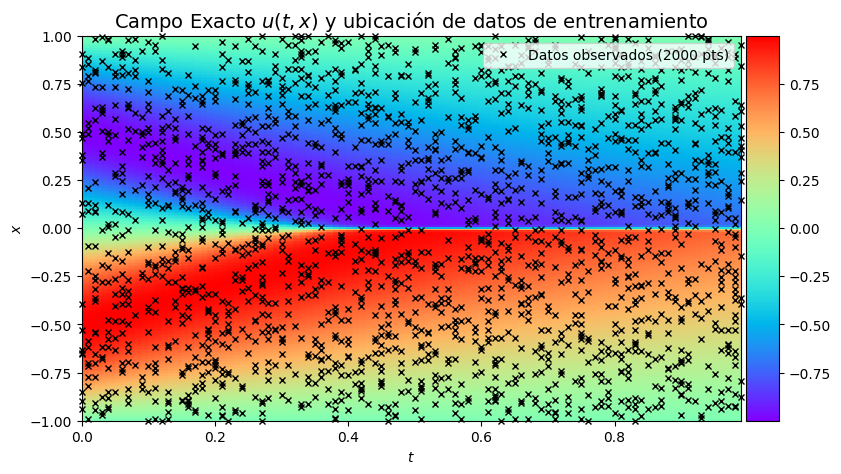

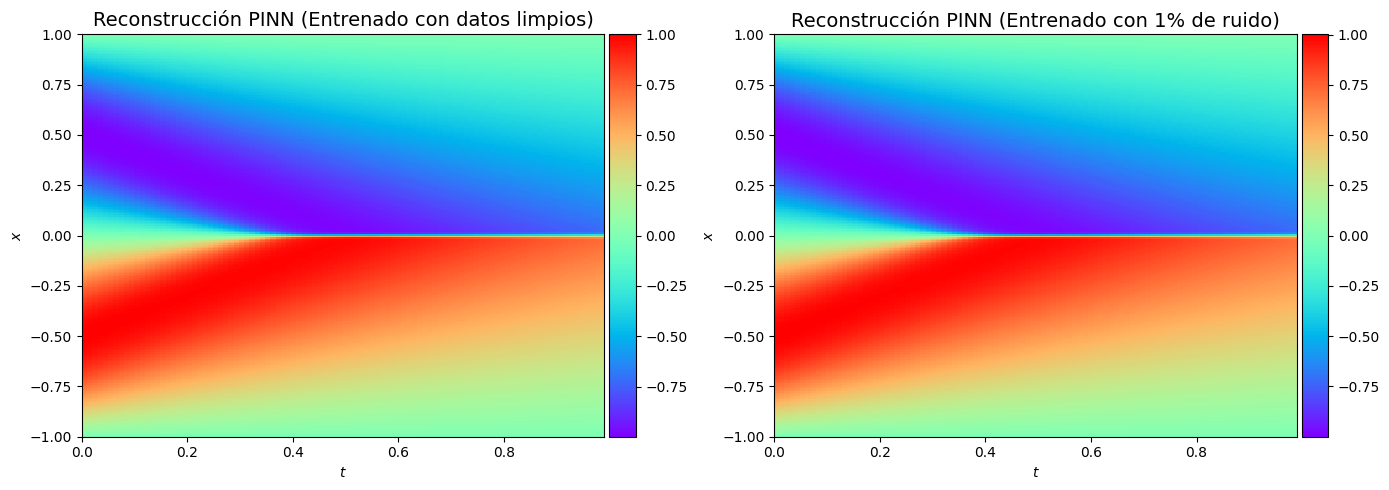

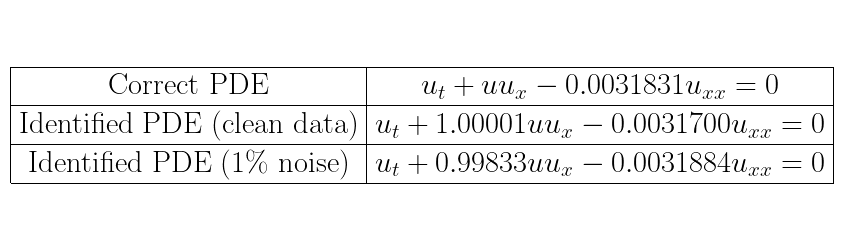

In [8]:
if __name__ == "__main__":

    nu = 0.01/np.pi

    N_u = 2000
    layers = [2, 20, 20, 20, 20, 20, 20, 20, 20, 1]

    data = scipy.io.loadmat('burgers_shock.mat')

    t = data['t'].flatten()[:,None]
    x = data['x'].flatten()[:,None]
    Exact = np.real(data['usol']).T

    X, T = np.meshgrid(x,t)

    X_star = np.hstack((X.flatten()[:,None], T.flatten()[:,None]))
    u_star = Exact.flatten()[:,None]

    # Doman bounds
    lb = X_star.min(0)
    ub = X_star.max(0)

    ######################################################################
    ######################## Noiseles Data ###############################
    ######################################################################
    noise = 0.0

    idx = np.random.choice(X_star.shape[0], N_u, replace=False)
    X_u_train = X_star[idx,:]
    u_train = u_star[idx,:]

    model = PhysicsInformedNN(X_u_train, u_train, layers, lb, ub)
    model.train(0)

    u_pred, f_pred = model.predict(X_star)

    error_u = np.linalg.norm(u_star-u_pred,2)/np.linalg.norm(u_star,2)

    U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')

    lambda_1_value = model.sess.run(model.lambda_1)[0]
    lambda_2_value = model.sess.run(model.lambda_2)[0]
    lambda_2_value = np.exp(lambda_2_value)

    error_lambda_1 = np.abs(lambda_1_value - 1.0)*100
    error_lambda_2 = np.abs(lambda_2_value - nu)/nu * 100

    print('Error u: %e' % (error_u))
    print('Error l1: %.5f%%' % (error_lambda_1))
    print('Error l2: %.5f%%' % (error_lambda_2))

    ######################################################################
    ########################### Noisy Data ###############################
    ######################################################################
    noise = 0.01
    u_train_noisy = u_train + noise*np.std(u_train)*np.random.randn(u_train.shape[0], u_train.shape[1])

    model.sess.close()         # 1. Cerramos la sesión del modelo anterior
    tf.reset_default_graph()   # 2. Destruimos el grafo para borrar las variables fantasma
    tf.set_random_seed(1234)   # 3. Restauramos la semilla de
    np.random.seed(1234)

    # Ahora instanciamos el modelo de manera segura y limpia
    model_noisy = PhysicsInformedNN(X_u_train, u_train_noisy, layers, lb, ub)
    model_noisy.train(10000)

    u_pred_noisy, f_pred_noisy = model_noisy.predict(X_star)

    lambda_1_value_noisy = model_noisy.sess.run(model_noisy.lambda_1)[0]
    lambda_2_value_noisy = model_noisy.sess.run(model_noisy.lambda_2)[0]
    lambda_2_value_noisy = np.exp(lambda_2_value_noisy)

    error_lambda_1_noisy = np.abs(lambda_1_value_noisy - 1.0)*100
    error_lambda_2_noisy = np.abs(lambda_2_value_noisy - nu)/nu * 100

    print('Error lambda_1: %f%%' % (error_lambda_1_noisy))
    print('Error lambda_2: %f%%' % (error_lambda_2_noisy))

    ######################################################################
    ############################# Plotting ###############################
    ######################################################################

    # Preparar las mallas de predicción (interpolar vectores a matrices 2D)
    U_pred = griddata(X_star, u_pred.flatten(), (X, T), method='cubic')
    U_pred_noisy = griddata(X_star, u_pred_noisy.flatten(), (X, T), method='cubic')

    # =========================================================
    # GRÁFICA 1: Campo Exacto con los datos ocultos (Sensores)
    # =========================================================
    fig1 = plt.figure(figsize=(9, 5))
    ax1 = fig1.add_subplot(111)

    # Usamos Exact.T para mapear la matriz original
    h1 = ax1.imshow(Exact.T, interpolation='nearest', cmap='rainbow',
                    extent=[t.min(), t.max(), x.min(), x.max()],
                    origin='lower', aspect='auto')

    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.05)
    fig1.colorbar(h1, cax=cax1)

    # Dibujar las cruces de los datos de entrenamiento
    ax1.plot(X_u_train[:,1], X_u_train[:,0], 'kx', markersize=4, clip_on=False, label='Datos observados (2000 pts)')

    ax1.set_xlabel('$t$')
    ax1.set_ylabel('$x$')
    ax1.set_title('Campo Exacto $u(t,x)$ y ubicación de datos de entrenamiento', fontsize=14)
    ax1.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.8)

    plt.show()

    # =========================================================
    # GRÁFICA 2: Campos reconstruidos (Limpio vs. Ruido)
    # =========================================================
    fig2 = plt.figure(figsize=(14, 5))

    # --- Subplot 1: Datos Limpios ---
    ax2 = fig2.add_subplot(121)
    h2 = ax2.imshow(U_pred.T, interpolation='nearest', cmap='rainbow',
                    extent=[t.min(), t.max(), x.min(), x.max()],
                    origin='lower', aspect='auto')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.05)
    fig2.colorbar(h2, cax=cax2)
    ax2.set_xlabel('$t$')
    ax2.set_ylabel('$x$')
    ax2.set_title('Reconstrucción PINN (Entrenado con datos limpios)', fontsize=14)

    # --- Subplot 2: Datos con 1% de Ruido ---
    ax3 = fig2.add_subplot(122)
    h3 = ax3.imshow(U_pred_noisy.T, interpolation='nearest', cmap='rainbow',
                    extent=[t.min(), t.max(), x.min(), x.max()],
                    origin='lower', aspect='auto')
    divider3 = make_axes_locatable(ax3)
    cax3 = divider3.append_axes("right", size="5%", pad=0.05)
    fig2.colorbar(h3, cax=cax3)
    ax3.set_xlabel('$t$')
    ax3.set_ylabel('$x$')
    ax3.set_title('Reconstrucción PINN (Entrenado con 1% de ruido)', fontsize=14)

    plt.tight_layout()
    plt.show()

    # =========================================================
    # GRÁFICA 3: Tabla de identificación de parámetros PDE (Estilo Original LaTeX)
    # =========================================================
    import matplotlib.pyplot as plt

    # Encendemos LaTeX con su fuente clásica
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman"]
    })

    fig3, ax4 = plt.subplots(figsize=(10, 3))
    ax4.axis('off')

    s1 = r'\begin{tabular}{ |c|c| }  \hline Correct PDE & $u_t + u u_x - 0.0031831 u_{xx} = 0$ \\  \hline Identified PDE (clean data) & '
    s2 = r'$u_t + %.5f u u_x - %.7f u_{xx} = 0$ \\  \hline ' % (lambda_1_value, lambda_2_value)
    s3 = r'Identified PDE (1\% noise) & '
    s4 = r'$u_t + %.5f u u_x - %.7f u_{xx} = 0$  \\  \hline ' % (lambda_1_value_noisy, lambda_2_value_noisy)
    s5 = r'\end{tabular}'

    s = s1 + s2 + s3 + s4 + s5

    ax4.text(0.5, 0.5, s, ha='center', va='center', fontsize=22)

    plt.savefig('Tabla_Burgers.pdf', bbox_inches='tight', pad_inches=0.1)
    plt.show()

    plt.rcParams.update({"text.usetex": False})

## 5. Extensión del Proyecto: Estudio de Identificabilidad y Escasez de Datos 🔬
Como **extensión a este experimento**, planteamos una pregunta crítica para la ingeniería real: *¿Cuántos sensores necesitamos realmente para que la red descubra la física correcta?*

En esta sección, realizamos un análisis de sensibilidad reduciendo drásticamente la cantidad de datos de entrenamiento disponibles ($N_u \in \{2000, 1000, 500, 100, 50, 20, 10\}$). En cada iteración, inicializamos y entrenamos una red desde cero para observar en qué punto la falta de información rompe la capacidad del modelo para inferir la viscosidad ($\lambda_2$) y la convección ($\lambda_1$).

In [9]:
import time

# Lista de cantidades de sensores que vamos a probar
N_u_list = [2000, 1000, 500, 100, 50, 20, 10]

# Listas para guardar los resultados
errors_l1 = []
errors_l2 = []

print("=== INICIANDO ESTUDIO DE IDENTIFICABILIDAD ===")

for n_sensors in N_u_list:
    print(f"\n--- Entrenando modelo con {n_sensors} sensores ---")

    # 1. Limpiar memoria de TensorFlow para evitar contaminación
    tf.reset_default_graph()
    tf.set_random_seed(1234)
    np.random.seed(1234)

    # 2. Seleccionar los N sensores aleatorios de los datos limpios
    idx = np.random.choice(X_star.shape[0], n_sensors, replace=False)
    X_u_train_exp = X_star[idx,:]
    u_train_exp = u_star[idx,:]

    # 3. Instanciar el modelo
    model_exp = PhysicsInformedNN(X_u_train_exp, u_train_exp, layers, lb, ub)

    # 4. Entrenar (usamos solo L-BFGS-B pasándole 0 iteraciones a Adam para acelerar)
    # L-BFGS-B suele ser suficiente si los datos son limpios
    model_exp.train(0)

    # 5. Extraer los parámetros descubiertos
    lambda_1_val = model_exp.sess.run(model_exp.lambda_1)[0]
    lambda_2_val = np.exp(model_exp.sess.run(model_exp.lambda_2)[0])

    # 6. Calcular errores (nu = 0.01/np.pi)
    err_l1 = np.abs(lambda_1_val - 1.0) * 100
    err_l2 = np.abs(lambda_2_val - nu) / nu * 100

    # Guardar para la gráfica final
    errors_l1.append(err_l1)
    errors_l2.append(err_l2)

    print(f"Resultado con {n_sensors} sensores -> Error L1: {err_l1:.2f}%, Error L2: {err_l2:.2f}%")

    # 7. Cerrar la sesión de este modelo
    model_exp.sess.close()

print("\n=== EXPERIMENTOS COMPLETADOS ===")

=== INICIANDO ESTUDIO DE IDENTIFICABILIDAD ===

--- Entrenando modelo con 2000 sensores ---


/tmp/ipykernel_40011/3071487642.py:158: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('Loss: %e, l1: %.5f, l2: %.5f' % (loss, lambda_1, np.exp(lambda_2)))


Loss: 1.962726e-02, l1: 0.27938, l2: 0.00268
Loss: 9.686725e-03, l1: 0.52876, l2: 0.00346
Loss: 5.206509e-03, l1: 0.78756, l2: 0.00525
Loss: 2.246519e-03, l1: 0.89637, l2: 0.00605
Loss: 1.044699e-03, l1: 0.94324, l2: 0.00511
Loss: 5.638593e-04, l1: 0.97718, l2: 0.00484
Loss: 3.422144e-04, l1: 0.97945, l2: 0.00448
Loss: 2.282382e-04, l1: 0.98803, l2: 0.00417
Loss: 1.657306e-04, l1: 0.99285, l2: 0.00391
Loss: 1.278570e-04, l1: 0.98660, l2: 0.00368
Loss: 1.096261e-04, l1: 0.99499, l2: 0.00358
Loss: 9.164125e-05, l1: 0.99134, l2: 0.00349
Loss: 7.946447e-05, l1: 0.99259, l2: 0.00337
Loss: 7.084070e-05, l1: 0.99402, l2: 0.00333
Loss: 5.924367e-05, l1: 0.99077, l2: 0.00325
Loss: 4.859475e-05, l1: 0.99410, l2: 0.00320
Loss: 4.152592e-05, l1: 0.99619, l2: 0.00318
Loss: 3.601726e-05, l1: 0.99544, l2: 0.00319
Loss: 3.191784e-05, l1: 0.99636, l2: 0.00319
Loss: 2.831986e-05, l1: 0.99688, l2: 0.00319
Loss: 2.525429e-05, l1: 0.99779, l2: 0.00320
Loss: 2.261971e-05, l1: 0.99858, l2: 0.00322
Loss: 2.09

<>:22: SyntaxWarning: invalid escape sequence '\%'
<>:22: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_40011/4111871447.py:22: SyntaxWarning: invalid escape sequence '\%'
  ax.set_ylabel('Error Relativo (\%)', fontsize=14)


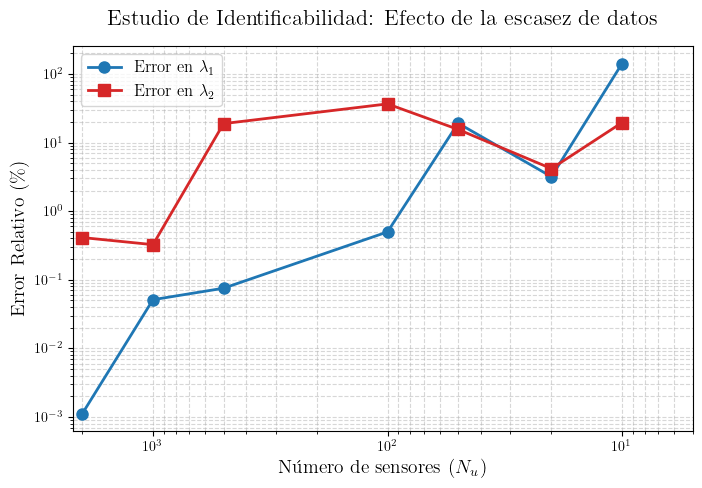

In [10]:
# Encendemos LaTeX para la gráfica
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"]
})

fig, ax = plt.subplots(figsize=(8, 5))

# Usamos escala logarítmica en el eje X porque los saltos de sensores son grandes
ax.plot(N_u_list, errors_l1, 'o-', color='tab:blue', linewidth=2, markersize=8, label=r'Error en $\lambda_1$')
ax.plot(N_u_list, errors_l2, 's-', color='tab:red', linewidth=2, markersize=8, label=r'Error en $\lambda_2$')

# Invertimos el eje X para que se lea de izquierda a derecha (de más datos a menos datos)
ax.set_xlim(2200, 5)
ax.set_xscale('log')

# Escala logarítmica también en Y para ver bien los errores pequeños y la explosión de error final
ax.set_yscale('log')

ax.set_xlabel('Número de sensores ($N_u$)', fontsize=14)
ax.set_ylabel('Error Relativo (\%)', fontsize=14)
ax.set_title('Estudio de Identificabilidad: Efecto de la escasez de datos', fontsize=16, pad=15)

ax.grid(True, which="both", ls="--", alpha=0.5)
ax.legend(fontsize=12, loc='upper left')

plt.savefig('Identificabilidad.pdf', bbox_inches='tight')
plt.show()

# Apagamos LaTeX
plt.rcParams.update({"text.usetex": False})

---
## 💡 Conclusiones Generales (Pista B y Extensión)

**Del Experimento Principal:**
1. **Poder de descubrimiento:** La PINN demostró ser altamente eficaz para resolver problemas inversos, logrando redescubrir la ecuación subyacente de Burgers a partir de mediciones dispersas.
2. **Robustez al ruido:** El término convectivo ($\lambda_1$) se mostró muy resiliente al ruido (1%), mientras que el término difusivo/viscoso ($\lambda_2$) sufrió una ligera desviación debido a la sensibilidad natural de las derivadas de segundo orden ante datos ruidosos.

**De la Extensión (Identificabilidad):**

3. **El límite de la información:** Como se observa en la última gráfica logarítmica, el modelo es capaz de sobrevivir con muchos menos de 2000 sensores. Sin embargo, existe un **punto de quiebre crítico** (alrededor de los 50-100 sensores). Por debajo de este umbral, el error en la estimación de $\lambda_2$ explota exponencialmente, indicando que el problema se vuelve matemáticamente no identificable.